In [1]:
#@title 1) Kurulum (train notebook'uyla aynı — pyrender/HMR2/IDM-VTON preprocess)
import os
if not os.path.exists('/content/MeshVTON'):
    !git clone https://github.com/SerhanTelatar/MeshVTON /content/MeshVTON
%cd /content/MeshVTON
!git pull

!pip -q install "diffusers>=0.34" "peft>=0.14" lpips einops sentencepiece trimesh smplx pyrender onnxruntime
!pip -q uninstall -y pyopengl PyOpenGL-accelerate > /dev/null 2>&1
!pip -q install "git+https://github.com/mmatl/pyopengl.git"
import importlib.util
if importlib.util.find_spec('hmr2') is None:
    !pip -q install "git+https://github.com/shubham-goel/4D-Humans.git"
!apt-get -qq install -y libglu1-mesa libosmesa6 > /dev/null 2>&1
import subprocess
_probe = subprocess.run(["python", "-c",
    'import os;os.environ["PYOPENGL_PLATFORM"]="egl";'
    'import pyrender;r=pyrender.OffscreenRenderer(16,16);r.delete();print("egl-ok")'],
    capture_output=True, text=True)
os.environ['PYOPENGL_PLATFORM'] = 'egl' if 'egl-ok' in _probe.stdout else 'osmesa'
print('GL platform:', os.environ['PYOPENGL_PLATFORM'])

if not os.path.exists('/content/IDM-VTON'):
    !git clone -q https://github.com/yisol/IDM-VTON /content/IDM-VTON
import shutil
from huggingface_hub import hf_hub_download
for repo_path in ('humanparsing/parsing_atr.onnx',
                  'humanparsing/parsing_lip.onnx',
                  'openpose/ckpts/body_pose_model.pth'):
    local = f'/content/IDM-VTON/ckpt/{repo_path}'
    if not (os.path.exists(local) and os.path.getsize(local) > 1_000_000):
        os.makedirs(os.path.dirname(local), exist_ok=True)
        shutil.copy(hf_hub_download('yisol/IDM-VTON', repo_path), local)
    assert os.path.getsize(local) > 1_000_000, f'bozuk indirme: {local}'

from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
print('Kurulum OK')

/content/MeshVTON
Already up to date.
  Preparing metadata (setup.py) ... done
GL platform: egl
Kurulum OK


In [2]:
#@title 2) Veri + TEMMUZ checkpoint'i
import os, sys, pathlib
sys.path.insert(0, '/content/MeshVTON/v2')
from google.colab import drive
drive.mount('/content/drive')
D = '/content/drive/MyDrive/MeshVTON'

!mkdir -p /content/MeshVTON/data
!unzip -q -n $D/garments_3d.zip -d /content/MeshVTON/data
!mkdir -p /content/MeshVTON/data/raw
!unzip -q -n $D/images.zip -d /content/MeshVTON/data/raw

!mkdir -p /content/MeshVTON/checkpoints/pretrained/smplx
!cp $D/smplx/SMPLX_NEUTRAL.* /content/MeshVTON/checkpoints/pretrained/smplx/
os.environ['SMPLX_MODEL_DIR'] = '/content/MeshVTON/checkpoints/pretrained/smplx'

import glob, shutil
from meshvton2.conditioning.body import _patch_torch_load_weights_only
import torch as _torch; _patch_torch_load_weights_only(_torch)
from hmr2.models import download_models
from hmr2.configs import CACHE_DIR_4DHUMANS
download_models(CACHE_DIR_4DHUMANS)
smpl_dir = f"{CACHE_DIR_4DHUMANS}/data/smpl"; os.makedirs(smpl_dir, exist_ok=True)
cands = glob.glob(f'{D}/smpl/*neutral*lbs*.pkl') + glob.glob(f'{D}/smpl/SMPL_NEUTRAL.pkl')
assert cands, "SMPL neutral pkl yok -> Drive/MeshVTON/smpl/"
shutil.copy(cands[0], f"{smpl_dir}/SMPL_NEUTRAL.pkl")

# TEMMUZ checkpoint'i — stage1/ ALTINDA DEĞİL (yeni eğitim rotasyonu orayı siliyor)
CHECKPOINT = f"{D}/v2_outputs/stage1_july/ckpt_004000.pt"  #@param {type:"string"}
assert os.path.exists(CHECKPOINT), (
    f"bulunamadi: {CHECKPOINT}\n"
    "Drive copunden geri yukleyip stage1_july/ altina tasidiniz mi?")
print('checkpoint:', CHECKPOINT, f"({os.path.getsize(CHECKPOINT)/1e6:.0f} MB)")

from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


checkpoint: /content/drive/MyDrive/MeshVTON/v2_outputs/stage1_july/ckpt_004000.pt (675 MB)


In [3]:
!python v2/scripts/build_golden_set.py \
    --vitonhd-test /content/MeshVTON/data/raw/images \
    --garments /content/MeshVTON/data/garments_3d

The golden set needs MANUAL curation for pose diversity (side/¾) and 2-3 non-VITON photos:
  write the selection to v2/configs/golden_persons.txt and edit it.
OK: 20 people × 5 garments × 4 angles = 400 evaluation items
Manifest: /content/MeshVTON/v2/data/golden/manifest.json (committed; the images are gitignored)


In [4]:
# 1) Mevcut manifest'i yedekle (tez ölçümleri buna dayanıyor)
!cp /content/MeshVTON/v2/data/golden/manifest.json /content/MeshVTON/v2/data/golden/manifest.AUG.json
!cp /content/MeshVTON/v2/data/golden/manifest.json /content/drive/MyDrive/MeshVTON/v2_outputs/manifest.AUG.json

# 2) Texture'ı OLAN giysileri bul
import pathlib
root = pathlib.Path('/content/MeshVTON/data/garments_3d/upper_body')
tex = [d for d in sorted(root.iterdir()) if d.is_dir() and any(d.glob('*.png'))]
print(f"{len(tex)} texture'lı giysi (toplam {sum(1 for d in root.iterdir() if d.is_dir())})")
for d in tex[:10]: print('  ', d.name)

114 texture'lı giysi (toplam 218)
   00111_Tshirt
   00126_Tshirt
   00259_Top
   00410_Tshirt
   00436_Top
   00682_Tshirt
   00761_Tshirt
   00833_Tshirt
   00928_Top
   00975_Top


In [5]:
IDS = ",".join(d.name for d in tex[:5])
print('secilen:', IDS)
!python /content/MeshVTON/v2/scripts/build_golden_set.py \
    --vitonhd-test /content/MeshVTON/data/raw/images \
    --garments /content/MeshVTON/data/garments_3d --garment-ids {IDS}

secilen: 00111_Tshirt,00126_Tshirt,00259_Top,00410_Tshirt,00436_Top
The golden set needs MANUAL curation for pose diversity (side/¾) and 2-3 non-VITON photos:
  write the selection to v2/configs/golden_persons.txt and edit it.
ERROR: the golden set is empty — check the paths


In [6]:
import pathlib
root = pathlib.Path('/content/MeshVTON/data/garments_3d/upper_body')
tex = [d for d in sorted(root.iterdir()) if d.is_dir() and any(d.glob('*.png'))]
IDS = ",".join(f"upper_body/{d.name}" for d in tex[:5])   # <-- kategori öneki ŞART
print('seçilen:', IDS)
!python /content/MeshVTON/v2/scripts/build_golden_set.py --vitonhd-test /content/MeshVTON/data/raw/images --garments /content/MeshVTON/data/garments_3d --garment-ids {IDS}

seçilen: upper_body/00111_Tshirt,upper_body/00126_Tshirt,upper_body/00259_Top,upper_body/00410_Tshirt,upper_body/00436_Top
The golden set needs MANUAL curation for pose diversity (side/¾) and 2-3 non-VITON photos:
  write the selection to v2/configs/golden_persons.txt and edit it.
OK: 20 people × 5 garments × 4 angles = 400 evaluation items
Manifest: /content/MeshVTON/v2/data/golden/manifest.json (committed; the images are gitignored)


INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`


giysi texture var mi: True 


100%|██████████| 1/1 [00:00<00:00,  1.78it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  b3 = torch.cross(b1, b2)


kişi | ESKİ (+0.06 / 1.00) | ref | KALİBRE (-0.12 / 1.25) | ref

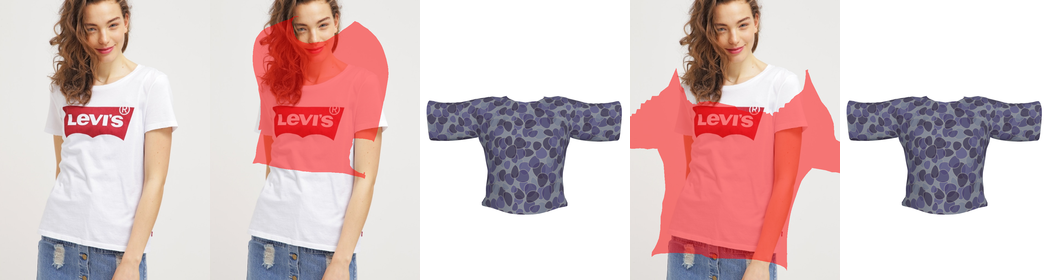

**Kırmızı silüet hangi ayarda gövdeye daha iyi oturuyorsa onu seç; `ref` panelleri RENKLİ olmalı** (gri ise texture yüklenmemiş).

In [7]:
#@title 3) Kişi + giysi seç, HİZALAMAYI kontrol et (difüzyon yok, ~1 dk)
# Temmuz checkpoint'i ESKİ koşullama rejiminde eğitildi (hang +0.06, ölçek 1.0,
# person_square_bbox düzeltmesinden ÖNCE). Ağustos kalibrasyonu (-0.12 / 1.25) ise
# BUGÜNKÜ foto yoluna göre ölçüldü. Hangisinin bu checkpoint'e uyduğu belirsiz —
# tahmin etmiyoruz, silüeti gövdeye bindirip GÖZLE seçiyoruz.
HANG_PAD      = -0.12  #@param {type:"number"}
GARMENT_SCALE = 1.25   #@param {type:"number"}
PERSON_ID     = "00000_00"  #@param {type:"string"}
GARMENT_ID = "upper_body__00111_Tshirt"  #@param {type:"string"}

import numpy as np, yaml, pathlib
from PIL import Image
from IPython.display import display, Markdown
from meshvton2.conditioning.body import build_hmr2_backend
from meshvton2.conditioning.builder import PhotoView, assert_real_impl, build_conditioning
from meshvton2.conditioning.garment import load_garment_asset
from meshvton2.conditioning.person import PersonPreprocessor, person_square_bbox
from meshvton2.eval.golden_set import load_manifest

REPO = pathlib.Path('/content/MeshVTON')
assert_real_impl()
base = yaml.safe_load((REPO/'v2/configs/base.yaml').read_text())
cfg  = yaml.safe_load((REPO/'v2/configs/eval.yaml').read_text())
size = (base['resolution']['height'], base['resolution']['width'])
man  = load_manifest(REPO/cfg['golden_manifest'])
GARMENTS_ROOT = REPO/base['paths']['garments_root']

g = globals()
if 'MV_PREP' not in g:
    g['MV_PREP'] = PersonPreprocessor('/content/IDM-VTON')
    g['MV_HMR2'] = build_hmr2_backend()
prep, hmr2 = g['MV_PREP'], g['MV_HMR2']

person = {p.id: p for p in man.persons}[PERSON_ID]
garment = {x.id: x for x in man.garments}[GARMENT_ID]
# TEXTURE'LI yükleme: bu checkpoint'in beklediği girdi bu
asset = load_garment_asset(GARMENTS_ROOT/garment.mesh,
                           texture_path=GARMENTS_ROOT/garment.texture if garment.texture else None,
                           garment_id=garment.id, allow_untextured=True)
print('giysi texture var mi:', asset.texture is not None,
      '' if asset.texture is not None else '  <-- YOK: use_texture faydasiz kalir')

pp = prep.process(man.root/person.image, size=size)
params = hmr2(pp.image, bbox=person_square_bbox(pp))
TH = 210; hh = round(TH*size[0]/size[1])
row = [('kişi', pp.image)]
for lbl, hp, sc in [('ESKİ (+0.06 / 1.00)', 0.06, 1.0), (f'KALİBRE ({HANG_PAD} / {GARMENT_SCALE})', HANG_PAD, GARMENT_SCALE)]:
    b = build_conditioning(pp.image, params, asset, PhotoView(), size=size, person_prep=pp,
                           hang_pad=hp, garment_scale=sc, use_texture=True)
    sil = b.control_depth_sil[2].numpy() > 0
    ov = pp.image.copy(); ov[sil] = (0.5*ov[sil] + 0.5*np.array([255,0,0])).astype(np.uint8)
    ref = ((b.appearance_ref.numpy().transpose(1,2,0)+1)/2*255).clip(0,255).astype(np.uint8)
    row += [(lbl, ov), ('ref', ref)]
strip = Image.new('RGB', (TH*len(row), hh), 'white')
for k,(_,a) in enumerate(row):
    strip.paste(Image.fromarray(a).convert('RGB').resize((TH,hh), Image.LANCZOS), (k*TH,0))
display(Markdown(' | '.join(l for l,_ in row)))
display(strip)
display(Markdown('**Kırmızı silüet hangi ayarda gövdeye daha iyi oturuyorsa onu seç; '
                 '`ref` panelleri RENKLİ olmalı** (gri ise texture yüklenmemiş).'))

In [8]:
!mkdir -p /content/MeshVTON/v2/data/golden/
!cp /content/drive/MyDrive/MeshVTON/v2_outputs/manifest.JULY.json /content/MeshVTON/v2/data/golden/manifest.json

FLUX + Temmuz checkpoint yükleniyor (~1 dk)...


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

FluxTrainModule ready — trainable params: 112,459,776
checkpoint loaded: /content/drive/MyDrive/MeshVTON/v2_outputs/stage1_july/ckpt_004000.pt (457 tensors)
2 giysi: ['upper_body__00111_Tshirt', 'upper_body__00126_Tshirt']
bitti upper_body__00111_Tshirt
bitti upper_body__00126_Tshirt


satır = giysi | sütunlar: **kişi** · **texture'lı referans** · **çıktı**

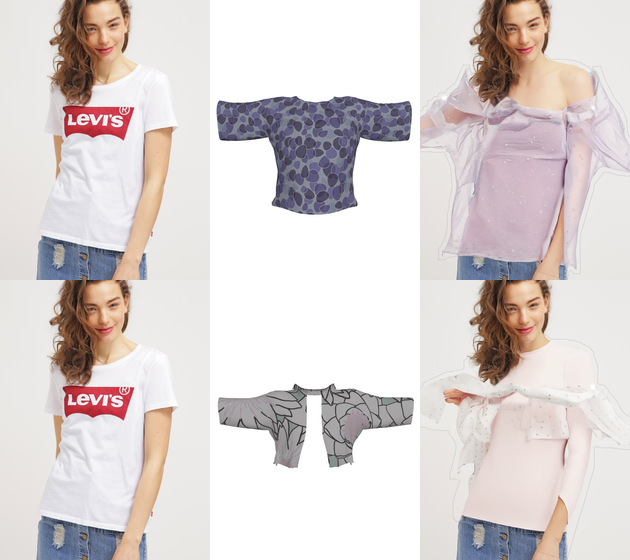

satır sırası: upper_body__00111_Tshirt · upper_body__00126_Tshirt

kaydedildi → /content/MeshVTON/v2/outputs/july_ckpt


In [9]:
#@title 4) Üret — texture'lı ref ile (Temmuz rejimi)
GARMENT_IDS = "upper_body__00047_Top, upper_body__00111_Tshirt, upper_body__00126_Tshirt"  #@param {type:"string"}
STEPS = 28  #@param {type:"integer"}
SEED  = 0   #@param {type:"integer"}

from meshvton2.model.flux_tryon import FluxTryOnSampler
if 'MV_SAMPLER_JULY' not in g:
    print('FLUX + Temmuz checkpoint yükleniyor (~1 dk)...')
    g['MV_SAMPLER_JULY'] = FluxTryOnSampler(base['model']['flux_fill_repo'],
                                            checkpoint=CHECKPOINT, prompt=base['model']['prompt'])
sampler = g['MV_SAMPLER_JULY']

OUT = REPO/'v2/outputs/july_ckpt'; OUT.mkdir(parents=True, exist_ok=True)
by_gid = {x.id: x for x in man.garments}
gids = [x.strip() for x in GARMENT_IDS.split(',') if x.strip() in by_gid]
print(f'{len(gids)} giysi:', gids)

rows = []
for gid in gids:
    gm = by_gid[gid]
    a = load_garment_asset(GARMENTS_ROOT/gm.mesh,
                           texture_path=GARMENTS_ROOT/gm.texture if gm.texture else None,
                           garment_id=gm.id, allow_untextured=True)
    b = build_conditioning(pp.image, params, a, PhotoView(), size=size, person_prep=pp,
                           hang_pad=HANG_PAD, garment_scale=GARMENT_SCALE, use_texture=True)
    out = sampler.sample(b, steps=STEPS, seed=SEED, control_scale=1.0)
    Image.fromarray(out).save(OUT/f'{PERSON_ID}__{gid}.png')
    ref = ((b.appearance_ref.numpy().transpose(1,2,0)+1)/2*255).clip(0,255).astype(np.uint8)
    rows.append((gid, ref, out))
    print('bitti', gid)

grid = Image.new('RGB', (TH*3, hh*len(rows)), 'white')
for r,(gid,ref,out) in enumerate(rows):
    for c,a in enumerate([pp.image, ref, out]):
        grid.paste(Image.fromarray(a).convert('RGB').resize((TH,hh), Image.LANCZOS), (c*TH, r*hh))
display(Markdown('satır = giysi | sütunlar: **kişi** · **texture\'lı referans** · **çıktı**'))
display(grid)
display(Markdown('satır sırası: ' + ' · '.join(g_ for g_,_,_ in rows)))
print('kaydedildi →', OUT)

In [10]:
!git pull
!python v2/scripts/eval_checkpoint.py --help | head -12

Already up to date.
usage: eval_checkpoint.py [-h] --checkpoint CHECKPOINT --idm-repo IDM_REPO
                          [--limit LIMIT] [--angles ANGLES [ANGLES ...]]
                          [--steps STEPS] [--hang-pad HANG_PAD]
                          [--garment-scale GARMENT_SCALE] [--use-texture]
                          [--tag-suffix TAG_SUFFIX]

Phase 4 exit gate — golden set evaluation with a trained checkpoint +
ablation. It runs and compares two passes: 1. control ON (control_scale=1.0)
2. control OFF (control_scale=0.0 — bit-identical stock behaviour thanks to
zero-init) GATE (the automated test of the v1 PHASE C lesson): if ON is worse
than OFF, training did not learn the geometry → do not move to Stage 2,
diagnose it (first remedy: raise ref_dropout). Usage (Colab, A100): python


In [11]:
#@title GECE KOŞUSU (tek hücre, düz yollar)
import gc, os, torch
for k in ['MV_SAMPLER_JULY','MV_SAMPLER','MV_HMR2','MV_PREP','sampler','prep','hmr2','b','asset']:
    globals().pop(k, None)
gc.collect(); torch.cuda.empty_cache(); torch.cuda.ipc_collect()
free, total = torch.cuda.mem_get_info()
print(f"GPU boş: {free/1e9:.1f} / {total/1e9:.1f} GB")
assert free/1e9 > 30, "GPU dolu → Runtime > Restart session, sonra hücre 1-2, sonra BU hücre"

for f in ["/content/drive/MyDrive/MeshVTON/v2_outputs/stage1_july/ckpt_004000.pt",
          "/content/drive/MyDrive/MeshVTON/v2_outputs/stage1/final.pt",
          "/content/MeshVTON/v2/data/golden/manifest.json"]:
    assert os.path.exists(f), f"YOK: {f}"
print("tüm girdiler yerinde\n")

GPU boş: 41.8 / 42.4 GB
tüm girdiler yerinde



In [12]:
# A1 — Temmuz, texture'lı (~32 dk)
!python v2/scripts/eval_checkpoint.py --checkpoint /content/drive/MyDrive/MeshVTON/v2_outputs/stage1_july/ckpt_004000.pt --idm-repo /content/IDM-VTON --limit 50 --use-texture --tag-suffix _july
!cp -r /content/MeshVTON/v2/eval_results /content/drive/MyDrive/MeshVTON/v2_outputs/

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  1.61it/s]
100% 1/1 [00:00<00:00,  2.45it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp

In [13]:
# A2 — Ağustos, dokusuz, aynı golden set (~32 dk)
!python v2/scripts/eval_checkpoint.py --checkpoint /content/drive/MyDrive/MeshVTON/v2_outputs/stage1/final.pt --idm-repo /content/IDM-VTON --limit 50 --tag-suffix _aug
!cp -r /content/MeshVTON/v2/eval_results /content/drive/MyDrive/MeshVTON/v2_outputs/

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  1.60it/s]
100% 1/1 [00:00<00:00,  1.75it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp

In [14]:
# B — ölçümler
!python v2/scripts/placement_iou.py --idm-repo /content/IDM-VTON --sets ckpt_control_on_july ckpt_control_off_july ckpt_control_on_aug ckpt_control_off_aug
!python v2/scripts/mesh_specificity.py --sets ckpt_control_on_july ckpt_control_off_july ckpt_control_on_aug ckpt_control_off_aug

=== PLACEMENT IoU (generated garment vs the person's real garment) ===
    DIFFERENCE from geo_iou: the target is not the silhouette we supplied, it is an independent parser.

100% 1/1 [00:00<00:00,  1.58it/s]
100% 1/1 [00:00<00:00,  1.76it/s]
100% 1/1 [00:00<00:00,  1.61it/s]
100% 1/1 [00:00<00:00,  1.77it/s]
100% 1/1 [00:00<00:00,  1.65it/s]
100% 1/1 [00:00<00:00,  1.81it/s]
100% 1/1 [00:00<00:00,  1.66it/s]
100% 1/1 [00:00<00:00,  1.81it/s]
100% 1/1 [00:00<00:00,  1.65it/s]
100% 1/1 [00:00<00:00,  1.84it/s]
100% 1/1 [00:00<00:00,  1.66it/s]
100% 1/1 [00:00<00:00,  1.82it/s]
100% 1/1 [00:00<00:00,  1.66it/s]
100% 1/1 [00:00<00:00,  1.83it/s]
100% 1/1 [00:00<00:00,  1.66it/s]
100% 1/1 [00:00<00:00,  1.82it/s]
100% 1/1 [00:00<00:00,  1.65it/s]
100% 1/1 [00:00<00:00,  1.84it/s]
100% 1/1 [00:00<00:00,  1.66it/s]
100% 1/1 [00:00<00:00,  2.62it/s]
ckpt_control_on_july         placement IoU = 0.5503  (n=50)
ckpt_control_off_july        placement IoU = 0.6381  (n=50)
ckpt_control_on_aug     

In [15]:
# C — figürler + son yedek
!python v2/scripts/make_figures.py --sets ckpt_control_on_july
!python v2/scripts/make_figures.py --sets ckpt_control_on_july ckpt_control_on_aug --limit-persons 4
!cp -r /content/MeshVTON/v2/eval_results /content/drive/MyDrive/MeshVTON/v2_outputs/
!cp /content/MeshVTON/v2/data/golden/manifest.json /content/drive/MyDrive/MeshVTON/v2_outputs/manifest.JULY.json
print("BİTTİ")

[1] /content/MeshVTON/v2/eval_results/figures/fig_persons__ckpt_control_on_july.png  (5 people × 5 garments × 1 sets)
[2] /content/MeshVTON/v2/eval_results/figures/fig_refs__ckpt_control_on_july.png  (15 combos)

NOTE: the reference panel is taken from the first set; if the sets are in different regimes (textured vs grey), state that in the figure caption.
[1] /content/MeshVTON/v2/eval_results/figures/fig_persons__ckpt_control_on_july_vs_ckpt_control_on_aug.png  (4 people × 5 garments × 2 sets)
[2] /content/MeshVTON/v2/eval_results/figures/fig_refs__ckpt_control_on_july_vs_ckpt_control_on_aug.png  (15 combos)

NOTE: the reference panel is taken from the first set; if the sets are in different regimes (textured vs grey), state that in the figure caption.
BİTTİ


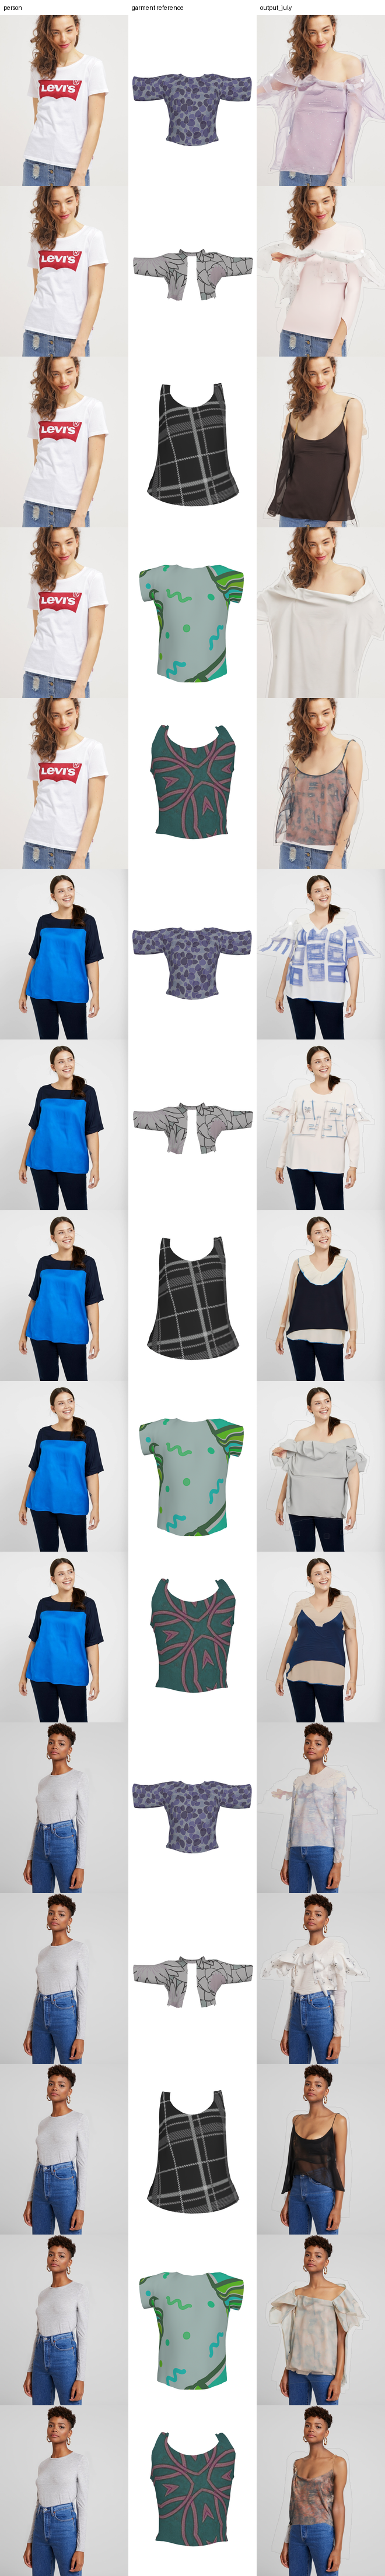

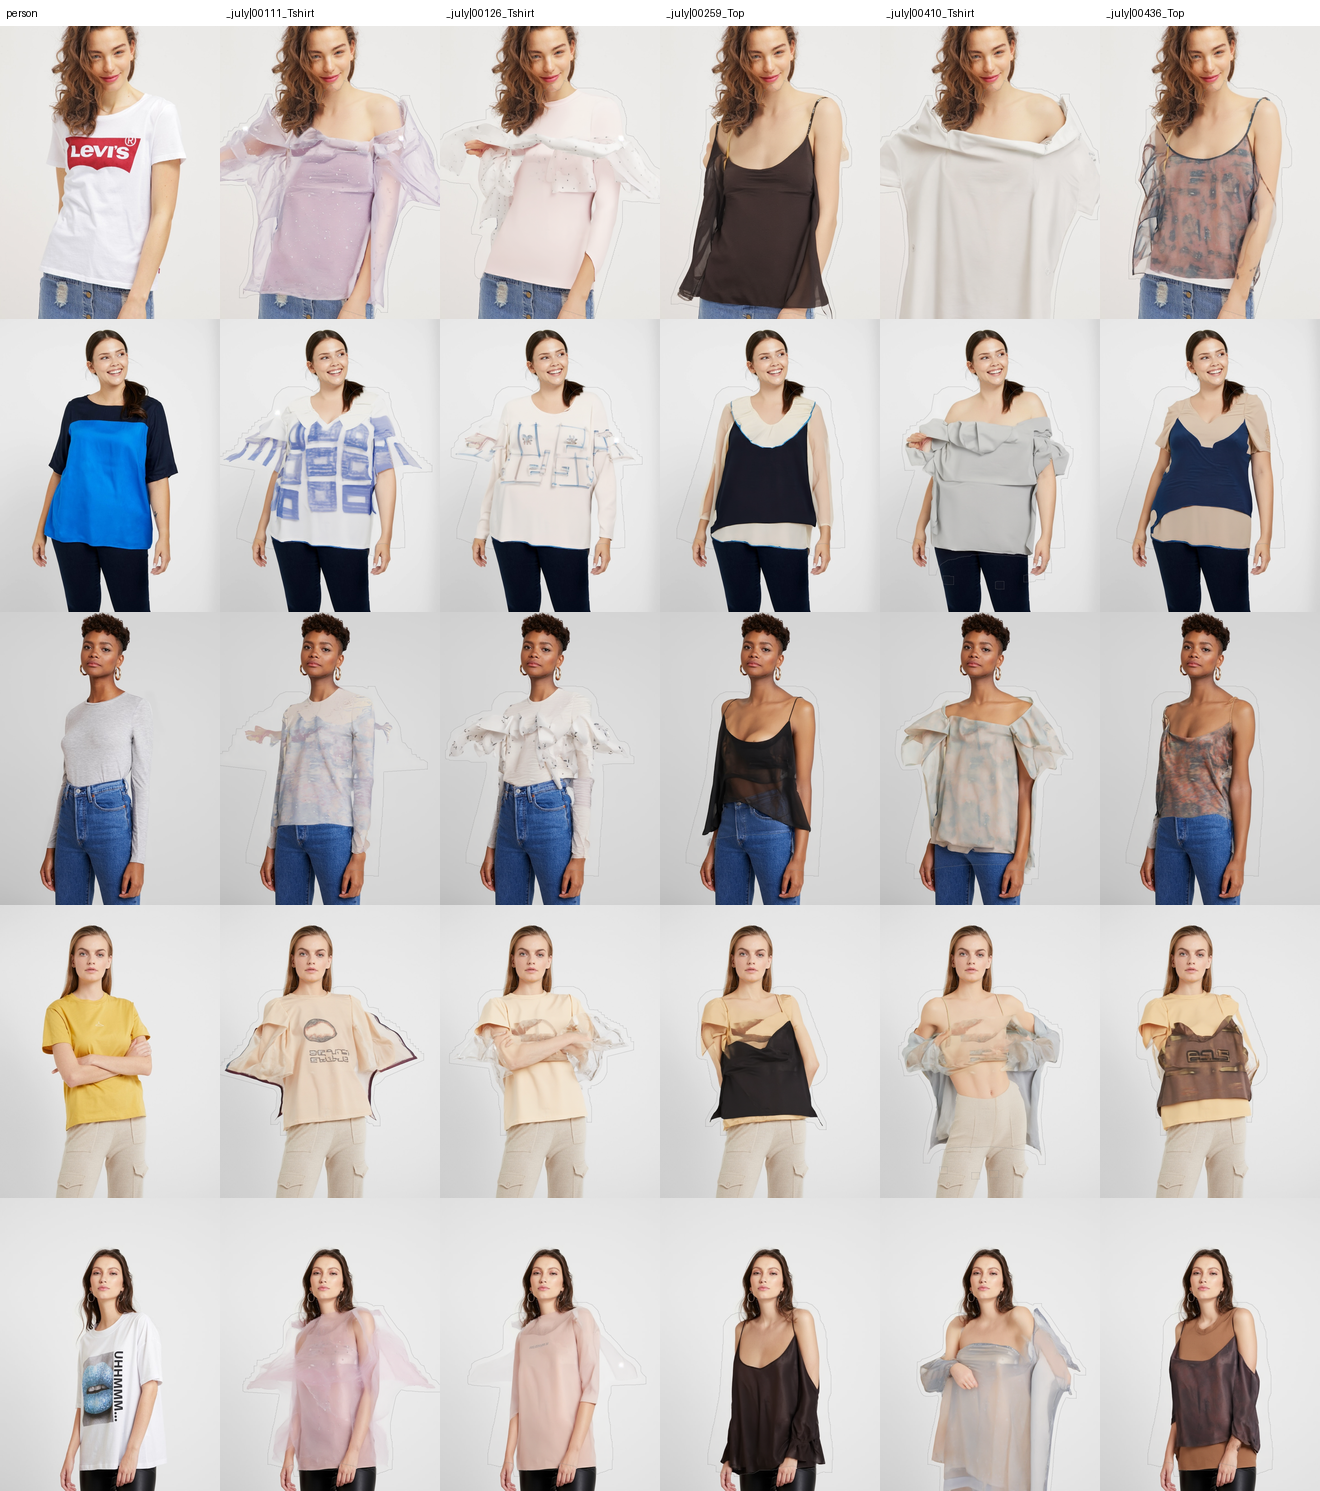

In [16]:
from IPython.display import Image as I, display
F = '/content/MeshVTON/v2/eval_results/figures/'
display(I(F+'fig_refs__ckpt_control_on_july.png', width=780))
display(I(F+'fig_persons__ckpt_control_on_july.png', width=980))

In [17]:
!python v2/scripts/zero_shot_baseline.py --variant fill_spatial --idm-repo /content/IDM-VTON
!python v2/scripts/backfill_baseline_geo.py --idm-repo /content/IDM-VTON
!python v2/scripts/mesh_specificity.py --sets phase1_fill_spatial ckpt_control_on_july ckpt_control_off_july
!cp -r /content/MeshVTON/v2/eval_results /content/drive/MyDrive/MeshVTON/v2_outputs/

100% 1/1 [00:00<00:00,  1.59it/s]
100% 1/1 [00:00<00:00,  1.76it/s]
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]
Loading weights: 100% 219/219 [00:00<00:00, 4936.97it/s]
Loading pipeline components...:  29% 2/7 [00:00<00:00,  8.34it/s]
Loading weights: 100% 196/196 [00:00<00:00, 4951.95it/s]
Loading pipeline components...:  86% 6/7 [00:00<00:00, 10.71it/s]
Loading checkpoint shards: 100% 3/3 [00:00<00:00, 34.84it/s]
Loading pipeline components...: 100% 7/7 [00:01<00:00,  6.83it/s]
100% 28/28 [00:19<00:00,  1.47it/s]
[1/100] 00000_00 × upper_body__00111_Tshirt OK
100% 28/28 [00:19<00:00,  1.47it/s]
[2/100] 00000_00 × upper_body__00126_Tshirt OK
100% 28/28 [00:19<00:00,  1.47it/s]

In [18]:
# 1) Kalibrasyon ablasyonu için eksik koşu — Temmuz ckpt, ESKİ hizalama (~32 dk)
!python v2/scripts/eval_checkpoint.py --checkpoint /content/drive/MyDrive/MeshVTON/v2_outputs/stage1_july/ckpt_004000.pt --idm-repo /content/IDM-VTON --limit 50 --use-texture --hang-pad 0.06 --garment-scale 1.0 --tag-suffix _july_nocal
!python v2/scripts/mesh_specificity.py --sets ckpt_control_on_july_nocal ckpt_control_on_july

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  2.63it/s]
100% 1/1 [00:00<00:00,  3.12it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp

In [19]:
# 2) Figür 5 — özgüllük matrisi (saniyeler)
!python v2/scripts/specificity_matrix.py --sets ckpt_control_on_july ckpt_control_off_july

ckpt_control_on_july: diagonal=0.7489 off-diagonal=0.5060 specificity=+0.2430
ckpt_control_off_july: diagonal=0.4663 off-diagonal=0.4151 specificity=+0.0513

/content/MeshVTON/v2/eval_results/figures/fig_specificity_matrix__00000_00.png
If the diagonal (white outlined) is bright, the model is SPECIFIC to the mesh it was given.


In [20]:
# 3) Figür 2 — kontrol açık/kapalı (saniyeler)
!python v2/scripts/make_figures.py --sets ckpt_control_on_july ckpt_control_off_july --limit-persons 4

[1] /content/MeshVTON/v2/eval_results/figures/fig_persons__ckpt_control_on_july_vs_ckpt_control_off_july.png  (4 people × 5 garments × 2 sets)
[2] /content/MeshVTON/v2/eval_results/figures/fig_refs__ckpt_control_on_july_vs_ckpt_control_off_july.png  (15 combos)

NOTE: the reference panel is taken from the first set; if the sets are in different regimes (textured vs grey), state that in the figure caption.


In [21]:
!cp -r /content/MeshVTON/v2/eval_results /content/drive/MyDrive/MeshVTON/v2_outputs/


In [22]:
import json
j = json.load(open('/content/MeshVTON/v2/eval_results/phase1_fill_spatial.json'))
print({k: round(v['mean'],2) for k,v in j['overall'].items() if v['mean'] is not None})

{'garment_delta_e': 14.82, 'geo_iou': 0.33, 'outside_mask_lpips': 0.0, 'outside_mask_psnr': 56.52, 'outside_mask_ssim': 1.0, 'silhouette_iou': 0.33}


In [23]:
#@title Tez figürlerini topla, adlandır, indir
import pathlib, shutil, glob
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt

E = pathlib.Path('/content/MeshVTON/v2/eval_results')
O = pathlib.Path('/content/MeshVTON/v2/outputs')
P = pathlib.Path('/content/paper_figures'); P.mkdir(exist_ok=True)

eslesme = {
    'fig_ablation.png':   E/'figures/fig_refs__ckpt_control_on_july_vs_ckpt_control_off_july.png',
    'fig_qual.png':       E/'figures/fig_refs__ckpt_control_on_july.png',
    'fig_persons.png':    E/'figures/fig_persons__ckpt_control_on_july.png',
    'fig_comparison.png': O/'comparison/comparison_grid.png',
    'architecture.png':   pathlib.Path('/content/MeshVTON/v2/docs/architecture_v2.png'),
}
m = glob.glob(str(E/'figures/fig_specificity_matrix__*.png'))
if m: eslesme['fig_specificity.png'] = pathlib.Path(m[0])

for hedef, kaynak in eslesme.items():
    if kaynak.exists():
        shutil.copy(kaynak, P/hedef); print(f'OK  {hedef}')
    else:
        print(f'EKSİK  {hedef}  <- {kaynak}')

# --- kalibrasyon figürü (sayılar taramalardan) ---
hang = [(-.30,.367),(-.27,.391),(-.24,.415),(-.21,.435),(-.18,.454),(-.15,.466),
        (-.12,.480),(-.09,.477),(-.06,.450),(-.03,.412),(0,.378),(.03,.340),
        (.06,.295),(.09,.251),(.12,.209)]
scale = [(.70,.306),(.75,.336),(.80,.367),(.85,.397),(.90,.419),(.95,.449),(1.00,.481),
         (1.05,.513),(1.10,.532),(1.15,.544),(1.20,.552),(1.25,.555),(1.30,.554),
         (1.35,.549),(1.40,.536),(1.45,.526),(1.50,.517),(1.55,.506),(1.60,.493),
         (1.65,.483),(1.70,.470)]
fig, ax = plt.subplots(1, 2, figsize=(8, 3.1))
for a, data, xl, inh, cal in [
        (ax[0], hang,  'garment hang offset [m]', 0.06, -0.12),
        (ax[1], scale, 'garment scale',           1.00,  1.25)]:
    x, y = zip(*data)
    a.plot(x, y, '-o', ms=3, color='#1f4e79')
    a.axvline(inh, ls='--', c='#999'); a.axvline(cal, ls='-', c='#c00', lw=1.2)
    a.annotate('inherited', (inh, min(y)), fontsize=7, color='#666',
               ha='center', va='bottom')
    a.annotate('calibrated', (cal, max(y)), fontsize=7, color='#c00',
               ha='center', va='top')
    a.set_xlabel(xl); a.grid(alpha=.3)
ax[0].set_ylabel('mesh–parser IoU')
fig.tight_layout(); fig.savefig(P/'fig_calibration.png', dpi=200)
print('OK  fig_calibration.png')

shutil.make_archive('/content/paper_figures', 'zip', P)
from google.colab import files; files.download('/content/paper_figures.zip')


OK  fig_ablation.png
OK  fig_qual.png
OK  fig_persons.png
EKSİK  fig_comparison.png  <- /content/MeshVTON/v2/outputs/comparison/comparison_grid.png
OK  architecture.png
OK  fig_specificity.png
OK  fig_calibration.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
!python v2/scripts/make_figures.py --sets ckpt_control_on_july
!python v2/scripts/make_figures.py --sets ckpt_control_on_july ckpt_control_off_july --limit-persons 4
!python v2/scripts/specificity_matrix.py --sets ckpt_control_on_july ckpt_control_off_july

[1] /content/MeshVTON/v2/eval_results/figures/fig_persons__ckpt_control_on_july.png  (5 people × 5 garments × 1 sets)
[2] /content/MeshVTON/v2/eval_results/figures/fig_refs__ckpt_control_on_july.png  (15 combos)

NOTE: the reference panel is taken from the first set; if the sets are in different regimes (textured vs grey), state that in the figure caption.
[1] /content/MeshVTON/v2/eval_results/figures/fig_persons__ckpt_control_on_july_vs_ckpt_control_off_july.png  (4 people × 5 garments × 2 sets)
[2] /content/MeshVTON/v2/eval_results/figures/fig_refs__ckpt_control_on_july_vs_ckpt_control_off_july.png  (15 combos)

NOTE: the reference panel is taken from the first set; if the sets are in different regimes (textured vs grey), state that in the figure caption.
ckpt_control_on_july: diagonal=0.7489 off-diagonal=0.5060 specificity=+0.2430
ckpt_control_off_july: diagonal=0.4663 off-diagonal=0.4151 specificity=+0.0513

/content/MeshVTON/v2/eval_results/figures/fig_specificity_matrix__00000_00

In [25]:
#@title Collect, rename and download paper figures
import pathlib, shutil, glob
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt

E = pathlib.Path('/content/MeshVTON/v2/eval_results')
O = pathlib.Path('/content/MeshVTON/v2/outputs')
P = pathlib.Path('/content/paper_figures'); P.mkdir(exist_ok=True)

mapping = {
    'fig_ablation.png':   E/'figures/fig_refs__ckpt_control_on_july_vs_ckpt_control_off_july.png',
    'fig_qual.png':       E/'figures/fig_refs__ckpt_control_on_july.png',
    'fig_persons.png':    E/'figures/fig_persons__ckpt_control_on_july.png',
    'fig_multiview.png':  O/'multiview/multiview_grid.png',
    'fig_comparison.png': O/'comparison/comparison_grid.png',
    'architecture.png':   pathlib.Path('/content/MeshVTON/v2/docs/architecture_v2.png'),
}
m = glob.glob(str(E/'figures/fig_specificity_matrix__*.png'))
if m: mapping['fig_specificity.png'] = pathlib.Path(m[0])

for dst, src in mapping.items():
    if src.exists():
        shutil.copy(src, P/dst); print(f'ok       {dst}')
    else:
        print(f'MISSING  {dst}   <- {src}')

# --- calibration figure (values from the two sweeps) ---
hang = [(-.30,.367),(-.27,.391),(-.24,.415),(-.21,.435),(-.18,.454),(-.15,.466),
        (-.12,.480),(-.09,.477),(-.06,.450),(-.03,.412),(0,.378),(.03,.340),
        (.06,.295),(.09,.251),(.12,.209)]
scale = [(.70,.306),(.75,.336),(.80,.367),(.85,.397),(.90,.419),(.95,.449),(1.00,.481),
         (1.05,.513),(1.10,.532),(1.15,.544),(1.20,.552),(1.25,.555),(1.30,.554),
         (1.35,.549),(1.40,.536),(1.45,.526),(1.50,.517),(1.55,.506),(1.60,.493),
         (1.65,.483),(1.70,.470)]
fig, ax = plt.subplots(1, 2, figsize=(8, 3.1))
for a, data, xlabel, inherited, calibrated in [
        (ax[0], hang,  'garment hang offset [m]', 0.06, -0.12),
        (ax[1], scale, 'garment scale',           1.00,  1.25)]:
    x, y = zip(*data)
    a.plot(x, y, '-o', ms=3, color='#1f4e79')
    a.axvline(inherited,  ls='--', c='#999999')
    a.axvline(calibrated, ls='-',  c='#cc0000', lw=1.2)
    a.annotate('inherited',  (inherited,  min(y)), fontsize=7, color='#666666',
               ha='center', va='bottom')
    a.annotate('calibrated', (calibrated, max(y)), fontsize=7, color='#cc0000',
               ha='center', va='top')
    a.set_xlabel(xlabel); a.grid(alpha=.3)
ax[0].set_ylabel('mesh-parser IoU')
fig.tight_layout(); fig.savefig(P/'fig_calibration.png', dpi=200)
print('ok       fig_calibration.png')

shutil.make_archive('/content/paper_figures', 'zip', P)
from google.colab import files; files.download('/content/paper_figures.zip')


ok       fig_ablation.png
ok       fig_qual.png
ok       fig_persons.png
MISSING  fig_multiview.png   <- /content/MeshVTON/v2/outputs/multiview/multiview_grid.png
MISSING  fig_comparison.png   <- /content/MeshVTON/v2/outputs/comparison/comparison_grid.png
ok       architecture.png
ok       fig_specificity.png
ok       fig_calibration.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FLUX + Temmuz checkpoint yükleniyor (~1 dk)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

FluxTrainModule ready — trainable params: 112,459,776
checkpoint loaded: /content/drive/MyDrive/MeshVTON/v2_outputs/stage1_july/ckpt_004000.pt (457 tensors)
2 giysi: ['upper_body__00111_Tshirt', 'upper_body__00126_Tshirt']
bitti upper_body__00111_Tshirt
bitti upper_body__00126_Tshirt


satır = giysi | sütunlar: **kişi** · **texture'lı referans** · **çıktı**

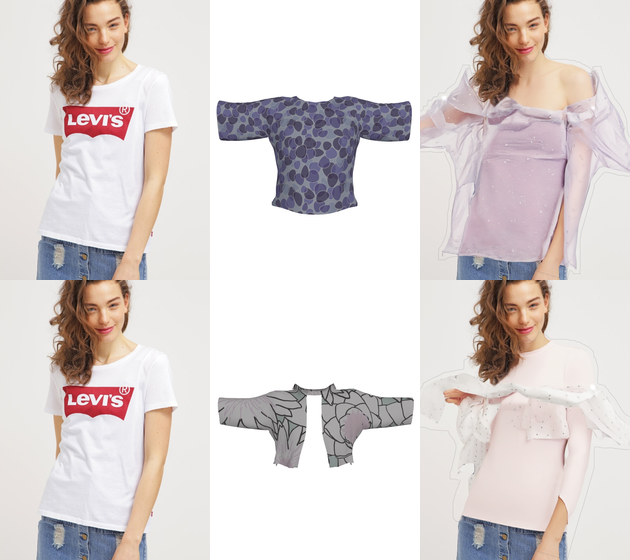

satır sırası: upper_body__00111_Tshirt · upper_body__00126_Tshirt

kaydedildi → /content/MeshVTON/v2/outputs/july_ckpt


In [26]:
#@title 4) Üret — texture'lı ref ile (Temmuz rejimi)
GARMENT_IDS = "upper_body__00047_Top, upper_body__00111_Tshirt, upper_body__00126_Tshirt"  #@param {type:"string"}
STEPS = 28  #@param {type:"integer"}
SEED  = 0   #@param {type:"integer"}

from meshvton2.model.flux_tryon import FluxTryOnSampler
if 'MV_SAMPLER_JULY' not in g:
    print('FLUX + Temmuz checkpoint yükleniyor (~1 dk)...')
    g['MV_SAMPLER_JULY'] = FluxTryOnSampler(base['model']['flux_fill_repo'],
                                            checkpoint=CHECKPOINT, prompt=base['model']['prompt'])
sampler = g['MV_SAMPLER_JULY']

OUT = REPO/'v2/outputs/july_ckpt'; OUT.mkdir(parents=True, exist_ok=True)
by_gid = {x.id: x for x in man.garments}
gids = [x.strip() for x in GARMENT_IDS.split(',') if x.strip() in by_gid]
print(f'{len(gids)} giysi:', gids)

rows = []
for gid in gids:
    gm = by_gid[gid]
    a = load_garment_asset(GARMENTS_ROOT/gm.mesh,
                           texture_path=GARMENTS_ROOT/gm.texture if gm.texture else None,
                           garment_id=gm.id, allow_untextured=True)
    b = build_conditioning(pp.image, params, a, PhotoView(), size=size, person_prep=pp,
                           hang_pad=HANG_PAD, garment_scale=GARMENT_SCALE, use_texture=True)
    out = sampler.sample(b, steps=STEPS, seed=SEED, control_scale=1.0)
    Image.fromarray(out).save(OUT/f'{PERSON_ID}__{gid}.png')
    ref = ((b.appearance_ref.numpy().transpose(1,2,0)+1)/2*255).clip(0,255).astype(np.uint8)
    rows.append((gid, ref, out))
    print('bitti', gid)

grid = Image.new('RGB', (TH*3, hh*len(rows)), 'white')
for r,(gid,ref,out) in enumerate(rows):
    for c,a in enumerate([pp.image, ref, out]):
        grid.paste(Image.fromarray(a).convert('RGB').resize((TH,hh), Image.LANCZOS), (c*TH, r*hh))
display(Markdown('satır = giysi | sütunlar: **kişi** · **texture\'lı referans** · **çıktı**'))
display(grid)
display(Markdown('satır sırası: ' + ' · '.join(g_ for g_,_,_ in rows)))
print('kaydedildi →', OUT)

Saving 05104_00_upper_body__00259_Top_000.person.png to 05104_00_upper_body__00259_Top_000.person.png
Saving Background.png to Background.png
Saving ChatGPT Image Jul 8, 2026, 10_51_07 PM.png to ChatGPT Image Jul 8, 2026, 10_51_07 PM.png
Saving ChatGPT Image Jul 8, 2026, 10_51_15 PM.png to ChatGPT Image Jul 8, 2026, 10_51_15 PM.png
4 görüş yüklendi
  05104_00_upper_body__00259_Top_000.person.png: 768x1024
  Background.png: 768x1024
  ChatGPT Image Jul 8, 2026, 10_51_07 PM.png: 1086x1448
  ChatGPT Image Jul 8, 2026, 10_51_15 PM.png: 1086x1448


INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100%|██████████| 1/1 [00:00<00:00,  1.85it/s]


bitti 05104_00_upper_body__00259_Top_000.person.png


100%|██████████| 1/1 [00:00<00:00,  1.85it/s]


bitti Background.png


100%|██████████| 1/1 [00:00<00:00,  1.84it/s]


bitti ChatGPT Image Jul 8, 2026, 10_51_07 PM.png


100%|██████████| 1/1 [00:00<00:00,  1.85it/s]


bitti ChatGPT Image Jul 8, 2026, 10_51_15 PM.png


satır = görüş | sütunlar: **kişi** · **mesh gövdeye giydirilmiş (normal)** · **MeshVTON çıktısı**

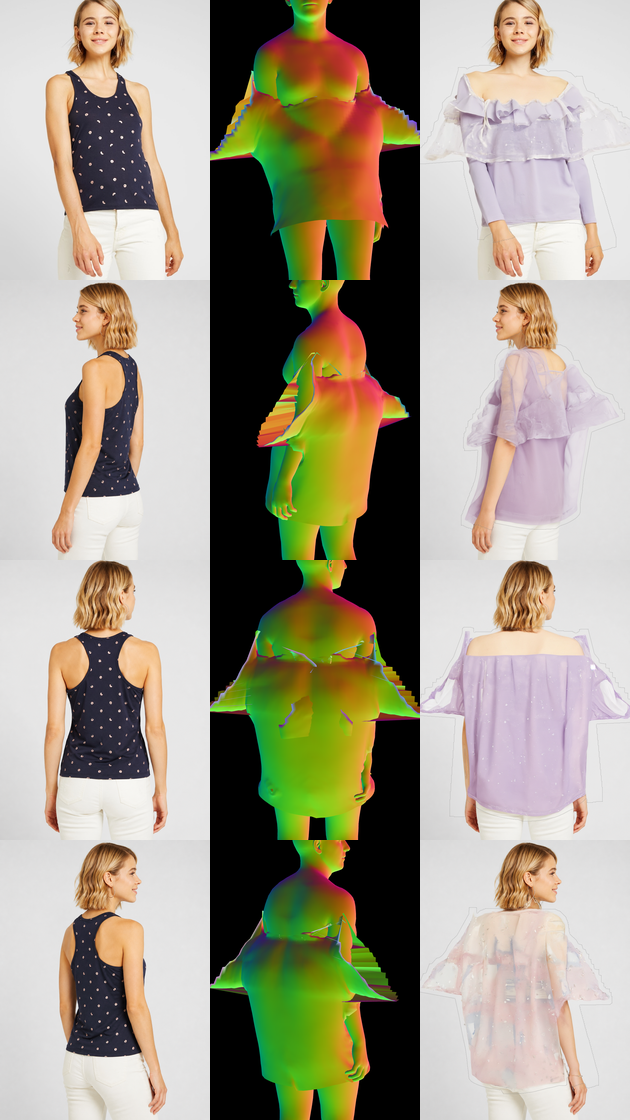

sıra: 05104_00_upper_body__00259_Top_000.person · Background · ChatGPT Image Jul 8, 2026, 10_51_07 PM · ChatGPT Image Jul 8, 2026, 10_51_15 PM

kaydedildi → /content/MeshVTON/v2/outputs/multiview


In [27]:
#@title 5) ÇOK-GÖRÜŞ — kendi fotoğraflarını yükle (aynı kişi, farklı açılar)
# Her fotoğraf BAĞIMSIZ işlenir: HMR2 o karenin pozunu ve kamerasını kestirir,
# giysi o gövdeye drape edilip o kameradan render edilir. Yani çok-görüş tutarlılığı
# "aynı mesh, farklı kamera" olarak gösterilir — rapordaki Fig 3'ün yerine geçer.
GARMENT_FOR_VIEWS = "upper_body__00111_Tshirt"  #@param {type:"string"}
STEPS_V = 28  #@param {type:"integer"}
SEED_V  = 0   #@param {type:"integer"}

import numpy as np, pathlib, gc, torch
from PIL import Image
from IPython.display import display, Markdown
from google.colab import files

up = pathlib.Path('/content/view_uploads'); up.mkdir(exist_ok=True)
VIEW_IMAGES = []
for name, data in files.upload().items():
    p = up / pathlib.Path(name).name
    p.write_bytes(data); VIEW_IMAGES.append(p)
assert VIEW_IMAGES, 'dosya yüklenmedi'
print(f'{len(VIEW_IMAGES)} görüş yüklendi')
for p in VIEW_IMAGES:
    w, h = Image.open(p).size
    print(f'  {p.name}: {w}x{h}' + ('' if abs(w/h-0.75) < 0.03 else '  DİKKAT: 3:4 değil, gerilecek'))

gm = {x.id: x for x in man.garments}[GARMENT_FOR_VIEWS]
asset_v = load_garment_asset(GARMENTS_ROOT/gm.mesh,
                             texture_path=GARMENTS_ROOT/gm.texture if gm.texture else None,
                             garment_id=gm.id, allow_untextured=True)

# Ensure `g` is defined and `prep`, `hmr2` are accessible
g = globals()
if 'MV_PREP' not in g:
    from meshvton2.conditioning.person import PersonPreprocessor
    from meshvton2.conditioning.body import build_hmr2_backend
    g['MV_PREP'] = PersonPreprocessor('/content/IDM-VTON')
    g['MV_HMR2'] = build_hmr2_backend()
prep = g['MV_PREP']
hmr2 = g['MV_HMR2']

if 'MV_SAMPLER_JULY' not in g:
    from meshvton2.model.flux_tryon import FluxTryOnSampler
    print('FLUX + Temmuz checkpoint yükleniyor...')
    g['MV_SAMPLER_JULY'] = FluxTryOnSampler(base['model']['flux_fill_repo'],
                                            checkpoint=CHECKPOINT, prompt=base['model']['prompt'])
sampler = g['MV_SAMPLER_JULY']

OUTV = REPO/'v2/outputs/multiview'; OUTV.mkdir(parents=True, exist_ok=True)
to_img = lambda t: ((t.numpy().transpose(1,2,0)+1)/2*255).clip(0,255).astype(np.uint8)
VIEW_RESULTS = {}
rows = []
for p in VIEW_IMAGES:
    try:
        ppv = prep.process(str(p), size=size)
        prm = hmr2(ppv.image, bbox=person_square_bbox(ppv))
    except Exception as e:
        print(f'ATLA {p.name}: {e}'); continue
    b = build_conditioning(ppv.image, prm, asset_v, PhotoView(), size=size, person_prep=ppv,
                           hang_pad=HANG_PAD, garment_scale=GARMENT_SCALE, use_texture=True)
    out = sampler.sample(b, steps=STEPS_V, seed=SEED_V, control_scale=1.0)
    Image.fromarray(out).save(OUTV/f'{p.stem}__{GARMENT_FOR_VIEWS}.png')
    VIEW_RESULTS[p.stem] = dict(person=ppv.image, agnostic=ppv.agnostic, mask=ppv.mask,
                                ref=to_img(b.appearance_ref), out=out)
    rows.append((p.stem, ppv.image, to_img(b.control_normal), out))
    print('bitti', p.name)

TH = 210; hh = round(TH*size[0]/size[1])
grid = Image.new('RGB', (TH*3, hh*len(rows)), 'white')
for r,(_,a,b_,c_) in enumerate(rows):
    for i,x in enumerate([a,b_,c_]):
        grid.paste(Image.fromarray(x).convert('RGB').resize((TH,hh), Image.LANCZOS), (i*TH, r*hh))
display(Markdown('satır = görüş | sütunlar: **kişi** · **mesh gövdeye giydirilmiş (normal)** · **MeshVTON çıktısı**'))
display(grid)
display(Markdown('sıra: ' + ' · '.join(n for n,_,_,_ in rows)))
print('kaydedildi →', OUTV)

  GPU free: 38.8 GB
fill_spatial yükleniyor...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

...

100%|██████████| 1/1 [00:00<00:00,  2.64it/s]


  MeshVTON × ChatGPT Image Jul 8, 2026, 10_51_07 PM


100%|██████████| 1/1 [00:00<00:00,  3.18it/s]


  MeshVTON × ChatGPT Image Jul 8, 2026, 10_51_15 PM


sütunlar: **kişi** · **giysi referansı** · **Fill (spatial)** · **MeshVTON kontrol KAPALI** · **MeshVTON kontrol AÇIK**

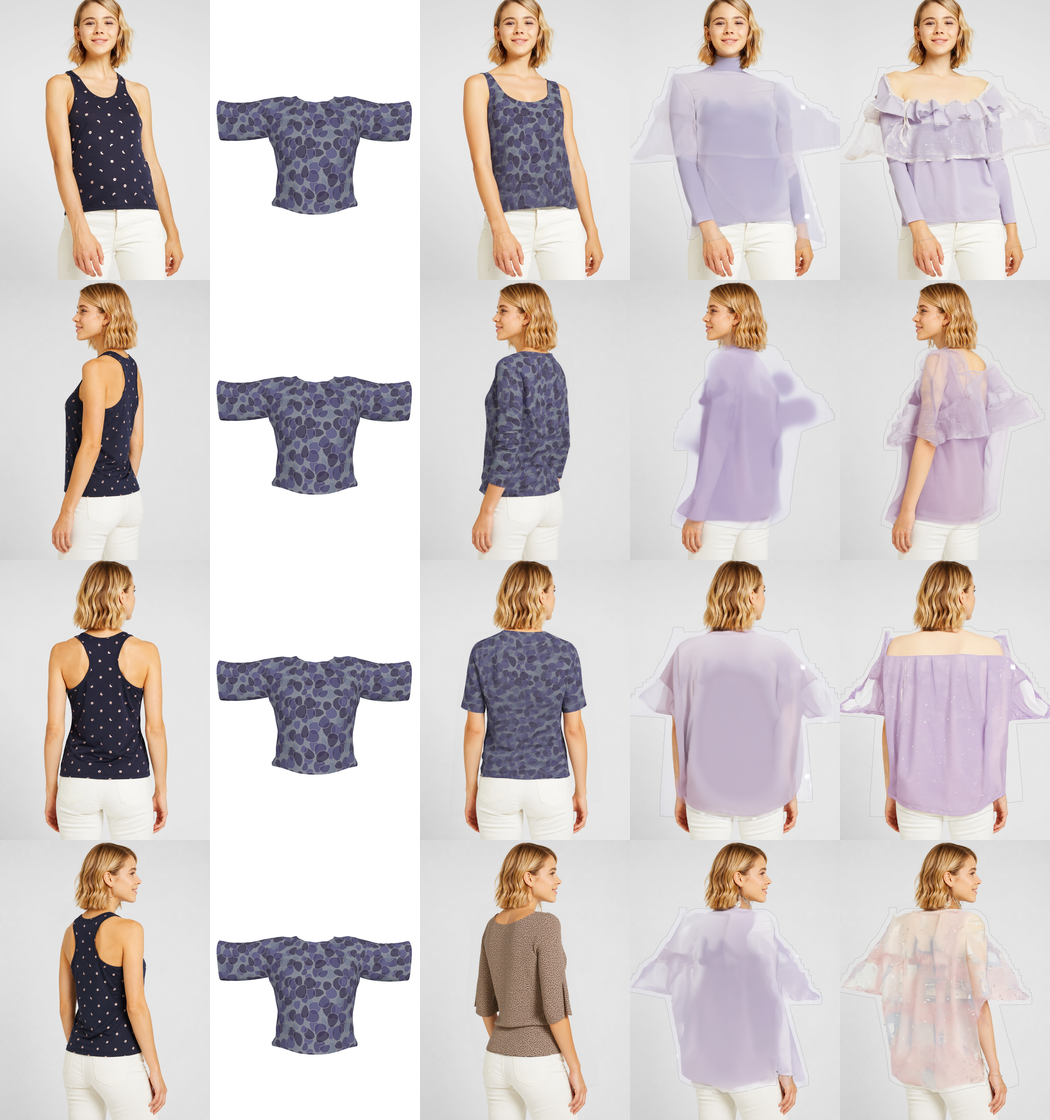

satır sırası: 05104_00_upper_body__00259_Top_000.person · Background · ChatGPT Image Jul 8, 2026, 10_51_07 PM · ChatGPT Image Jul 8, 2026, 10_51_15 PM

kaydedildi → /content/MeshVTON/v2/outputs/comparison


In [28]:
#@title 6) MODEL KARŞILAŞTIRMA — aynı görüşlerde baseline'lar vs MeshVTON
# GPU 40GB'a üç FLUX birden sığmaz: modeller SIRAYLA yüklenir, her birinden sonra bellek
# boşaltılır. Kontext ayrı bir repo indirir (~24GB), yavaşsa RUN_KONTEXT=False yapın.
RUN_FILL    = True   #@param {type:"boolean"}
RUN_KONTEXT = False  #@param {type:"boolean"}
RUN_OURS_OFF = True  #@param {type:"boolean"}

assert VIEW_RESULTS, 'önce hücre 5\'i çalıştırın'
import gc, torch
from meshvton2.model.flux_tryon import FluxTryOn

def free():
    # Ad listesiyle temizlemek KIRILGAN: aynı model nesnesi farklı hücrelerde
    # farklı adlarla tutuluyor (sampler, _smp, MV_SAMPLER_JULY...). Bir tanesi
    # kaçarsa bellek boşalmaz. Bu yüzden TİPE göre tarıyoruz.
    from meshvton2.model.flux_tryon import FluxTryOn, FluxTryOnSampler
    ns = globals()
    for k, v in list(ns.items()):
        if isinstance(v, (FluxTryOn, FluxTryOnSampler)):
            ns.pop(k, None)
    # IPython çıktı geçmişi (Out/_/__) da nesneye referans tutabilir
    try:
        ip = get_ipython()
        ip.user_ns.get('Out', {}).clear()
        for k in ('_', '__', '___'):
            ip.user_ns[k] = None
    except Exception:
        pass
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.ipc_collect()
    freeb = torch.cuda.mem_get_info()[0] / 1e9
    print(f'  GPU free: {freeb:.1f} GB')
    if freeb < 28:
        raise RuntimeError(
            f'yalnız {freeb:.1f} GB boş — ikinci bir FLUX sığmaz. '
            'Runtime > Restart session yapıp hücre 1-2-3-5 sonra 6 koşun '
            '(hücre 4 ve 7 ATLAYIN, onlar da kernel içine model yüklüyor).')

COMP = {k: {} for k in VIEW_RESULTS}

# --- eğitimsiz baseline'lar (kendi FluxTryOn'ları) ---
for flag, variant in [(RUN_FILL, 'fill_spatial'), (RUN_KONTEXT, 'kontext')]:
    if not flag: continue
    free()
    print(f'{variant} yükleniyor...')
    m = FluxTryOn(variant, fill_repo=base['model']['flux_fill_repo'],
                  kontext_repo=base['model']['flux_kontext_repo'], device=base['device'], steps=28)
    for k, d in VIEW_RESULTS.items():
        COMP[k][variant] = m.tryon(d['person'], d['agnostic'], d['mask'], d['ref'], seed=SEED_V)
        print(f'  {variant} × {k}')
    del m; free()

# --- bizim model: kontrol kapalı ve açık ---
from meshvton2.model.flux_tryon import FluxTryOnSampler
print('MeshVTON yükleniyor...')
smp = FluxTryOnSampler(base['model']['flux_fill_repo'], checkpoint=CHECKPOINT,
                       prompt=base['model']['prompt'])
for k, d in VIEW_RESULTS.items():
    src = next((q for q in pathlib.Path('/content/view_uploads').glob(k+'.*')), None)
    ppv = prep.process(str(src), size=size)
    prm = hmr2(ppv.image, bbox=person_square_bbox(ppv))
    b = build_conditioning(ppv.image, prm, asset_v, PhotoView(), size=size, person_prep=ppv,
                           hang_pad=HANG_PAD, garment_scale=GARMENT_SCALE, use_texture=True)
    if RUN_OURS_OFF:
        COMP[k]['ours_off'] = smp.sample(b, steps=28, seed=SEED_V, control_scale=0.0)
    COMP[k]['ours_on'] = smp.sample(b, steps=28, seed=SEED_V, control_scale=1.0)
    print(f'  MeshVTON × {k}')

# --- ızgara ---
cols = ['person', 'ref'] + [c for c in ['fill_spatial','kontext','ours_off','ours_on']
                            if any(c in v for v in COMP.values())]
labels = {'person':'kişi','ref':'giysi referansı','fill_spatial':'Fill (spatial)',
          'kontext':'Kontext','ours_off':'MeshVTON kontrol KAPALI','ours_on':'MeshVTON kontrol AÇIK'}
OUTC = REPO/'v2/outputs/comparison'; OUTC.mkdir(parents=True, exist_ok=True)
grid = Image.new('RGB', (TH*len(cols), hh*len(COMP)), 'white')
for r,(k,d) in enumerate(COMP.items()):
    src = VIEW_RESULTS[k]
    for c,name in enumerate(cols):
        a = src.get(name) if name in ('person','ref') else d.get(name)
        if a is None: continue
        grid.paste(Image.fromarray(a).convert('RGB').resize((TH,hh), Image.LANCZOS), (c*TH, r*hh))
        if name not in ('person','ref'):
            Image.fromarray(a).save(OUTC/f'{k}__{name}.png')
grid.save(OUTC/'comparison_grid.png')
display(Markdown('sütunlar: ' + ' · '.join(f'**{labels[c]}**' for c in cols)))
display(grid)
display(Markdown('satır sırası: ' + ' · '.join(COMP)))
print('kaydedildi →', OUTC)

In [29]:
#@title 7) DEMO — upload your own photos (front / side / back) and dress them
# Her fotoğraf BAĞIMSIZ işlenir: HMR2 o karenin pozunu ve kamerasını kestirir, giysi
# o gövdeye drape edilip o kameradan render edilir. Yani arkadan verdiğin fotoğrafta
# giysinin arkası, yandan verdiğinde yanı üretilir — azimut tahmini yok, kamera dönüyor.
# Kendi kendine yeterli: eksik nesneleri kendi kurar. ÖNCE hücre 1-2 koşmuş olmalı.
DEMO_GARMENTS = "upper_body__00111_Tshirt, upper_body__00259_Top"  #@param {type:"string"}
DEMO_STEPS = 28  #@param {type:"integer"}
DEMO_SEED  = 0   #@param {type:"integer"}

import sys, pathlib, shutil, yaml, numpy as np
sys.path.insert(0, '/content/MeshVTON/v2')
from PIL import Image
from IPython.display import display, Markdown
from google.colab import files
from meshvton2.conditioning.body import build_hmr2_backend
from meshvton2.conditioning.builder import PhotoView, assert_real_impl, build_conditioning
from meshvton2.conditioning.garment import load_garment_asset
from meshvton2.conditioning.person import PersonPreprocessor, person_square_bbox
from meshvton2.model.flux_tryon import FluxTryOnSampler
from meshvton2.eval.golden_set import load_manifest

assert_real_impl()
REPO = pathlib.Path('/content/MeshVTON')
_base = yaml.safe_load((REPO/'v2/configs/base.yaml').read_text())
_cfg  = yaml.safe_load((REPO/'v2/configs/eval.yaml').read_text())
_size = (_base['resolution']['height'], _base['resolution']['width'])
_man  = load_manifest(REPO/_cfg['golden_manifest'])
_GR   = REPO/_base['paths']['garments_root']
_HP   = globals().get('HANG_PAD', -0.12)        # hücre 3'te seçtiğin değerler
_GS   = globals().get('GARMENT_SCALE', 1.25)
_CK   = globals().get('CHECKPOINT',
        '/content/drive/MyDrive/MeshVTON/v2_outputs/stage1_july/ckpt_004000.pt')
print(f'checkpoint={pathlib.Path(_CK).name}  hang={_HP}  scale={_GS}')

g = globals()
if 'MV_PREP' not in g: g['MV_PREP'] = PersonPreprocessor('/content/IDM-VTON')
if 'MV_HMR2' not in g: g['MV_HMR2'] = build_hmr2_backend()
if 'MV_SAMPLER_JULY' not in g:
    print('loading FLUX + checkpoint (~1 min, first time only)...')
    g['MV_SAMPLER_JULY'] = FluxTryOnSampler(_base['model']['flux_fill_repo'],
                                            checkpoint=_CK, prompt=_base['model']['prompt'])
_prep, _hmr2, _smp = g['MV_PREP'], g['MV_HMR2'], g['MV_SAMPLER_JULY']

by_gid = {x.id: x for x in _man.garments}
gids = [x.strip() for x in DEMO_GARMENTS.split(',') if x.strip() in by_gid]
missing = [x.strip() for x in DEMO_GARMENTS.split(',') if x.strip() and x.strip() not in by_gid]
if missing: print('SKIPPED (not in manifest):', missing)
assert gids, f'no valid garment. available: {list(by_gid)[:5]}'
assets = {gid: load_garment_asset(_GR/by_gid[gid].mesh,
            texture_path=_GR/by_gid[gid].texture if by_gid[gid].texture else None,
            garment_id=gid, allow_untextured=True) for gid in gids}
print(f'{len(gids)} garment(s):', gids)

# --- upload: baytları kendimiz yazıyoruz (files.upload çalışma dizinine koyar) ---
UP = pathlib.Path('/content/demo_uploads')
shutil.rmtree(UP, ignore_errors=True); UP.mkdir(parents=True)
paths = []
for name, data in files.upload().items():
    p = UP/pathlib.Path(name).name; p.write_bytes(data); paths.append(p)
assert paths, 'no file uploaded'

OUT = REPO/'v2/outputs/demo'; shutil.rmtree(OUT, ignore_errors=True); OUT.mkdir(parents=True)
TH = 220; hh = round(TH*_size[0]/_size[1])
rows = []
for p in sorted(paths):
    w, h = Image.open(p).size
    if abs(w/h - 0.75) > 0.03:
        print(f'  WARNING {p.name}: aspect {w/h:.2f}, expected 3:4 = 0.75 (will be stretched)')
    try:
        pp = _prep.process(str(p), size=_size)
        prm = _hmr2(pp.image, bbox=person_square_bbox(pp))
    except Exception as e:
        print(f'  SKIP {p.name}: person not detected — {e}'); continue
    outs = []
    for gid in gids:
        b = build_conditioning(pp.image, prm, assets[gid], PhotoView(), size=_size,
                               person_prep=pp, hang_pad=_HP, garment_scale=_GS,
                               use_texture=True)
        o = _smp.sample(b, steps=DEMO_STEPS, seed=DEMO_SEED, control_scale=1.0)
        Image.fromarray(o).save(OUT/f'{p.stem}__{gid}.png')
        outs.append(o)
        print(f'  done {p.name} x {gid}')
    rows.append((p.stem, pp.image, outs))

assert rows, 'no photo could be processed'
grid = Image.new('RGB', (TH*(1+len(gids)), hh*len(rows)), 'white')
for r,(_, person, outs) in enumerate(rows):
    for c, a in enumerate([person] + outs):
        grid.paste(Image.fromarray(a).convert('RGB').resize((TH,hh), Image.LANCZOS), (c*TH, r*hh))
grid.save(OUT/'demo_grid.png')
display(Markdown('columns: **input photo** · ' + ' · '.join(f'**{x.split("__")[-1]}**' for x in gids)))
display(grid)
display(Markdown('rows: ' + ' · '.join(n for n,_,_ in rows)))

shutil.make_archive('/content/demo_results', 'zip', OUT)
print('\nsaved ->', OUT)
files.download('/content/demo_results.zip')

checkpoint=ckpt_004000.pt  hang=-0.12  scale=1.25
loading FLUX + checkpoint (~1 min, first time only)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 72.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 41.44 MiB is free. Including non-PyTorch memory, this process has 39.44 GiB memory in use. Of the allocated memory 38.93 GiB is allocated by PyTorch, and 11.02 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [30]:
!git pull
!python v2/scripts/specificity_matrix.py --sets ckpt_control_on_july ckpt_control_off_july

Already up to date.
ckpt_control_on_july: diagonal=0.7489 off-diagonal=0.5060 specificity=+0.2430
ckpt_control_off_july: diagonal=0.4663 off-diagonal=0.4151 specificity=+0.0513

/content/MeshVTON/v2/eval_results/figures/fig_specificity_matrix__00000_00.png
If the diagonal (white outlined) is bright, the model is SPECIFIC to the mesh it was given.


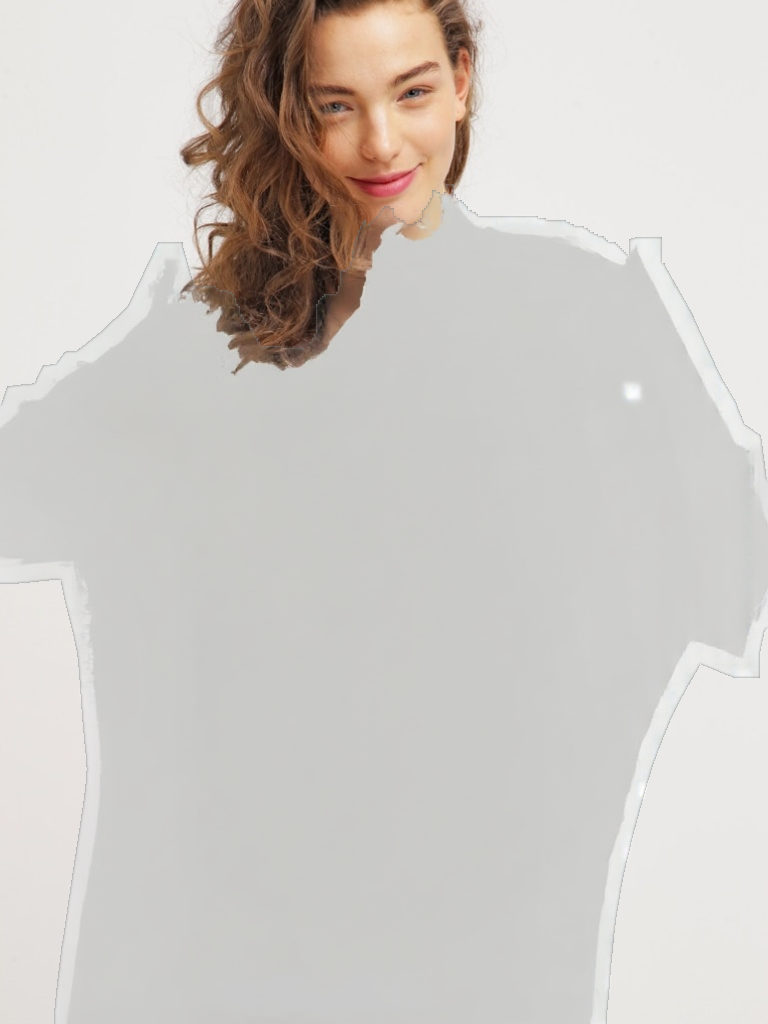

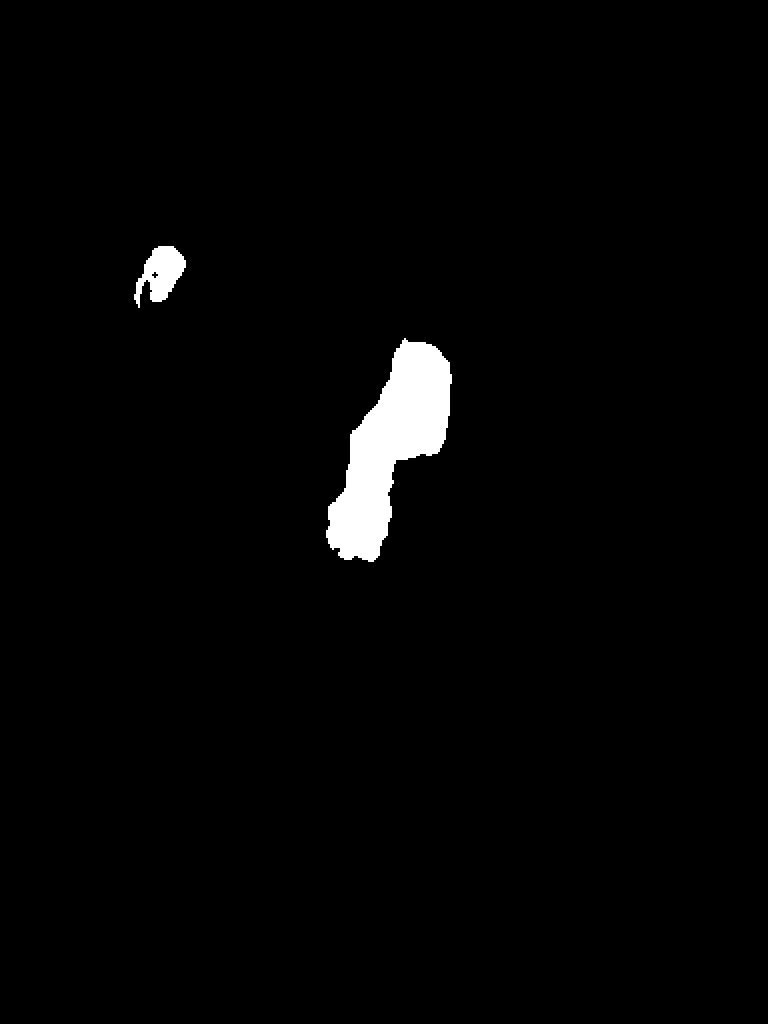

In [31]:
from IPython.display import Image as I, display
P = '/content/MeshVTON/v2/eval_results/ckpt_control_off_july/preds/'
display(I(P+'00000_00_upper_body__00410_Tshirt_000.png', width=300))
display(I(P+'00000_00_upper_body__00410_Tshirt_000.predsil.png', width=300))

In [32]:
#@title Parser başarısızlık oranı — dejenere predsil sayımı
import numpy as np, pathlib
from PIL import Image
E = pathlib.Path('/content/MeshVTON/v2/eval_results')
for s in ['ckpt_control_on_july','ckpt_control_off_july',
          'ckpt_control_on_july_nocal','phase1_fill_spatial']:
    d = E/s/'preds'
    if not d.exists(): continue
    areas = []
    for p in sorted(d.glob('*.predsil.png')):
        m = np.asarray(Image.open(p).convert('L')) > 127
        areas.append(m.mean())
    if not areas: continue
    a = np.array(areas)
    print(f'{s:30s} n={len(a):3d}  ortalama alan=%{a.mean()*100:5.1f}  '
          f'dejenere(<%2)={int((a<0.02).sum()):2d}  (%{(a<0.02).mean()*100:.0f})')

ckpt_control_on_july           n= 50  ortalama alan=% 23.4  dejenere(<%2)= 0  (%0)
ckpt_control_off_july          n= 50  ortalama alan=% 26.8  dejenere(<%2)= 1  (%2)
ckpt_control_on_july_nocal     n= 50  ortalama alan=% 21.6  dejenere(<%2)= 0  (%0)
phase1_fill_spatial            n=100  ortalama alan=% 16.3  dejenere(<%2)= 0  (%0)


In [33]:
!python v2/scripts/mesh_specificity.py --sets ckpt_control_on_july ckpt_control_off_july --per-person
!python v2/scripts/specificity_matrix.py --sets ckpt_control_on_july ckpt_control_off_july --person 01455_00

=== MESH SPECIFICITY (diagonal = correct mesh, higher is better) ===

ckpt_control_on_july
  correct mesh (diagonal)     = 0.7000  (n=50)
  wrong mesh   (off-diagonal) = 0.4806  (n=200)
  SPECIFICITY                 = +0.2194  (+45.7%)
    00000_00     5 garments: correct=0.7489 wrong=0.5060 diff=+0.2430
    00737_00     5 garments: correct=0.5801 wrong=0.4835 diff=+0.0967
    01455_00     5 garments: correct=0.6863 wrong=0.4479 diff=+0.2384
    02199_00     5 garments: correct=0.5393 wrong=0.4049 diff=+0.1344
    02935_00     5 garments: correct=0.7102 wrong=0.4948 diff=+0.2154
    03659_00     5 garments: correct=0.7941 wrong=0.5284 diff=+0.2656
    04384_00     5 garments: correct=0.7545 wrong=0.4854 diff=+0.2692
    05104_00     5 garments: correct=0.7845 wrong=0.4972 diff=+0.2873
    05836_00     5 garments: correct=0.7592 wrong=0.5103 diff=+0.2488
    06577_00     5 garments: correct=0.6429 wrong=0.4476 diff=+0.1953

ckpt_control_off_july
  correct mesh (diagonal)     = 0.5241  (

In [34]:
#@title Predsil alan dağılımı — kuyruk kontrolü
import numpy as np, pathlib
from PIL import Image
E = pathlib.Path('/content/MeshVTON/v2/eval_results')
for s in ['ckpt_control_on_july','ckpt_control_off_july',
          'ckpt_control_on_july_nocal','phase1_fill_spatial']:
    d = E/s/'preds'
    if not d.exists(): continue
    a = np.array([ (np.asarray(Image.open(p).convert('L'))>127).mean()
                   for p in sorted(d.glob('*.predsil.png')) ])
    if not len(a): continue
    med = np.median(a)
    print(f'{s:30s} n={len(a):3d}  medyan=%{med*100:4.1f}  '
          f'min=%{a.min()*100:4.1f}  p5=%{np.percentile(a,5)*100:4.1f}  '
          f'medyanın yarısından küçük={int((a<med/2).sum()):2d} (%{(a<med/2).mean()*100:.0f})')


ckpt_control_on_july           n= 50  medyan=%21.5  min=%10.0  p5=%11.2  medyanın yarısından küçük= 2 (%4)
ckpt_control_off_july          n= 50  medyan=%26.0  min=% 2.0  p5=%14.8  medyanın yarısından küçük= 2 (%4)
ckpt_control_on_july_nocal     n= 50  medyan=%20.9  min=% 6.2  p5=% 9.2  medyanın yarısından küçük= 3 (%6)
phase1_fill_spatial            n=100  medyan=%17.3  min=% 3.9  p5=% 6.1  medyanın yarısından küçük= 8 (%8)


In [35]:
import json
m = json.load(open('/content/MeshVTON/v2/data/golden/manifest.json'))
print([(g['id'], g['texture'] is not None) for g in m['garments']])

[('upper_body__00111_Tshirt', True), ('upper_body__00126_Tshirt', True), ('upper_body__00259_Top', True), ('upper_body__00410_Tshirt', True), ('upper_body__00436_Top', True)]


In [36]:
!cp /content/drive/MyDrive/MeshVTON/v2_outputs/manifest.JULY.json /content/MeshVTON/v2/data/golden/manifest.json


In [41]:
!python v2/scripts/eval_checkpoint.py \
    --checkpoint /content/drive/MyDrive/MeshVTON/v2_outputs/stage1_july/ckpt_004000.pt \
    --idm-repo /content/IDM-VTON --limit 100 --use-texture --tag-suffix _july
!cp -r /content/MeshVTON/v2/eval_results /content/drive/MyDrive/MeshVTON/v2_outputs/
!python v2/scripts/mesh_specificity.py --sets ckpt_control_on_july ckpt_control_off_july --per-person
!python v2/scripts/placement_iou.py --idm-repo /content/IDM-VTON --sets ckpt_control_on_july ckpt_control_off_july
!cp -r /content/MeshVTON/v2/eval_results /content/drive/MyDrive/MeshVTON/v2_outputs/

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
Traceback (most recent call last):
  File "/content/MeshVTON/v2/scripts/eval_checkpoint.py", line 184, in <module>
    raise SystemExit(main())
                     ^^^^^^
  File "/content/MeshVTON/v2/scripts/eval_checkpoint.py", line 118, in main
    hmr2 = build_hmr2_backend()
           ^^^^^^^^^^^^^^^^^^^^
  File "/content/MeshVTON/v2/meshvton2/conditioning/body.py", line 72, in build_hmr2_backend
    model = model.to(device).eval()
